In [3]:
!pip install gensim 


In [1]:

!pip install tensorflow

In [5]:
!pip install nltk

import nltk
import pandas as pd
import numpy as np
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec # Import the Word2Vec class from gensim.models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [6]:
!pip install tensorflow

In [7]:
!pip install pandas


In [9]:
import pandas as pd

# Load your dataset (replace 'your_dataset.csv' with your file path)
df = pd.read_csv('dataset.csv')

# Print column names
print(df.columns)


Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [11]:
for column in df.columns:
    print(column)


 Destination Port
 Flow Duration
 Total Fwd Packets
 Total Backward Packets
Total Length of Fwd Packets
 Total Length of Bwd Packets
 Fwd Packet Length Max
 Fwd Packet Length Min
 Fwd Packet Length Mean
 Fwd Packet Length Std
Bwd Packet Length Max
 Bwd Packet Length Min
 Bwd Packet Length Mean
 Bwd Packet Length Std
Flow Bytes/s
 Flow Packets/s
 Flow IAT Mean
 Flow IAT Std
 Flow IAT Max
 Flow IAT Min
Fwd IAT Total
 Fwd IAT Mean
 Fwd IAT Std
 Fwd IAT Max
 Fwd IAT Min
Bwd IAT Total
 Bwd IAT Mean
 Bwd IAT Std
 Bwd IAT Max
 Bwd IAT Min
Fwd PSH Flags
 Bwd PSH Flags
 Fwd URG Flags
 Bwd URG Flags
 Fwd Header Length
 Bwd Header Length
Fwd Packets/s
 Bwd Packets/s
 Min Packet Length
 Max Packet Length
 Packet Length Mean
 Packet Length Std
 Packet Length Variance
FIN Flag Count
 SYN Flag Count
 RST Flag Count
 PSH Flag Count
 ACK Flag Count
 URG Flag Count
 CWE Flag Count
 ECE Flag Count
 Down/Up Ratio
 Average Packet Size
 Avg Fwd Segment Size
 Avg Bwd Segment Size
 Fwd Header Length.1
Fwd Avg

In [15]:
!pip install kares


In [17]:
!pip install gensim

In [19]:
!pip install nltk

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, Bidirectional

# Parameters (adjust based on your dataset)
vocab_size = 10000  # Set this based on the tokenizer's vocabulary size
embedding_dim = 100  # Dimensionality of word embeddings
max_sequence_length = 100  # Length of padded sequences
num_classes = 2  # Number of output classes (binary classification as an example)

# Build the RNN model
model = Sequential()

# Step 1: Embedding Layer
# Convert word indices into dense vectors of fixed size
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))

# Step 2: LSTM/GRU Layer
# Add LSTM or GRU layers to process the sequences
# You can also use Bidirectional RNNs for improved performance
model.add(Bidirectional(LSTM(128, return_sequences=False)))  # Try GRU here if preferred

# Step 3: Dense Layers for Classification
# Fully connected layers to learn complex patterns
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))  # Dropout to prevent overfitting
model.add(Dense(num_classes, activation='softmax'))  # Use 'sigmoid' for binary classification

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])  # Use 'binary_crossentropy' for binary

# Summary of the model
model.summary()


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 100, 100)          1000000   
_________________________________________________________________
bidirectional (Bidirectional (None, 256)               234496    
_________________________________________________________________
dense (Dense)                (None, 64)                16448     
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 2)                 130       
Total params: 1,251,074
Trainable params: 1,251,074
Non-trainable params: 0
_________________________________________________________________


In [27]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load your dataset
dataset = pd.read_csv('dataset.csv')

# Step 1: Select Relevant Columns
# Replace this list with the actual numerical columns you want to process
# Added leading/trailing spaces to match the actual column names in the dataset
numerical_columns = [
    ' Destination Port', ' Flow Duration', ' Total Fwd Packets',
    ' Total Backward Packets', 'Total Length of Fwd Packets',
    ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
    ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
    ' Fwd Packet Length Std', 'Bwd Packet Length Max',
    ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
    ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
    ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
    # Add more numerical columns here if needed
]

# Ensure the selected columns are in the dataset
numerical_data = dataset[numerical_columns]

# Step 2: Normalize the Data
# Normalize numerical data to a range (e.g., 0 to 1)
normalized_data = (numerical_data - numerical_data.min()) / (numerical_data.max() - numerical_data.min())

# Step 3: Prepare Data for Model Input
# Convert the numerical data into sequences (e.g., rows are treated as sequences)
# This step assumes the rows represent time steps or features
sequences = normalized_data.values

# Step 4: Sequence Padding
# Pad sequences to ensure uniform input size if necessary
# Typically for numerical data, padding might not be needed unless you're dealing with time-series data of varying lengths
max_sequence_length = sequences.shape[1]  # Use the number of columns as the sequence length
padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post', dtype='float32')

# Output: padded_sequences is ready for input into a model
print(f"Padded sequences shape: {padded_sequences.shape}")


Padded sequences shape: (1042557, 20)


In [29]:
 import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, Bidirectional

# Assuming you have preprocessed your labels into one-hot encoded format for multi-class classification
# Assuming 'Label' column contains your labels
dataset = pd.read_csv('dataset.csv')
labels = pd.get_dummies(dataset[' Label']) # Extract labels from 'Label' column and one-hot encode using pandas get_dummies

# Update num_classes to match the actual number of classes in your data
num_classes = labels.shape[1]  # Get the number of columns in the one-hot encoded labels

# Parameters (adjust based on your dataset)
vocab_size = 100 # Set this based on the tokenizer's vocabulary size
embedding_dim = 10  # Dimensionality of word embeddings
max_sequence_length = 1000  # Length of padded sequences

# Build the RNN model
model = Sequential()

# Step 1: Embedding Layer
# Convert word indices into dense vectors of fixed size
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))

# Step 2: LSTM/GRU Layer
# Add LSTM or GRU layers to process the sequences
# You can also use Bidirectional RNNs for improved performance
model.add(Bidirectional(LSTM(100, return_sequences=False)))  # Try GRU here if preferred

# Step 3: Dense Layers for Classification
# Fully connected layers to learn complex patterns
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))  # Dropout to prevent overfitting

# Update the final Dense layer to have the correct number of output units before compiling
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])  # Use 'binary_crossentropy' for binary

# Summary of the model
model.summary()

# ... (rest of your code) ...

history = model.fit(padded_sequences, labels, epochs=10, batch_size=32, validation_split=0.2)

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, 1000, 10)          1000      
_________________________________________________________________
bidirectional_1 (Bidirection (None, 200)               88800     
_________________________________________________________________
dense_2 (Dense)              (None, 64)                12864     
_________________________________________________________________
dropout_1 (Dropout)          (None, 64)                0         
_________________________________________________________________
dense_3 (Dense)              (None, 4)                 260       
Total params: 102,924
Trainable params: 102,924
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10
26064/26064 [==============================] - 1059s 40ms/step - loss: 1.2065 - accuracy: 0.5152 - val_

In [46]:
print("Maximum value in dataset:", dataset.max().max())
print("Minimum value in dataset:", dataset.min().min())
print("Are there any infinite values? \n", dataset.isin([np.inf, -np.inf]).any())


Maximum value in dataset: inf
Minimum value in dataset: -193000000.0
Are there any infinite values? 
 0     False
1     False
2     False
3     False
4     False
      ...  
73    False
74    False
75    False
76    False
77    False
Length: 78, dtype: bool


In [48]:
# Replace infinite values with NaN
dataset.replace([np.inf, -np.inf], np.nan, inplace=True)

# Option 1: Drop rows with NaN
dataset.dropna(inplace=True)

# Option 2: Fill NaN with a fixed value (e.g., 0 or mean of the column)
# dataset.fillna(dataset.mean(), inplace=True)


In [7]:
threshold = 1e6  # Example threshold, adjust as needed
dataset = dataset.clip(upper=threshold, lower=-threshold)


C:\Users\aadil\AppData\Local\Temp\ipykernel_35184\1426432525.py:7: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv('dataset.csv', header=None)


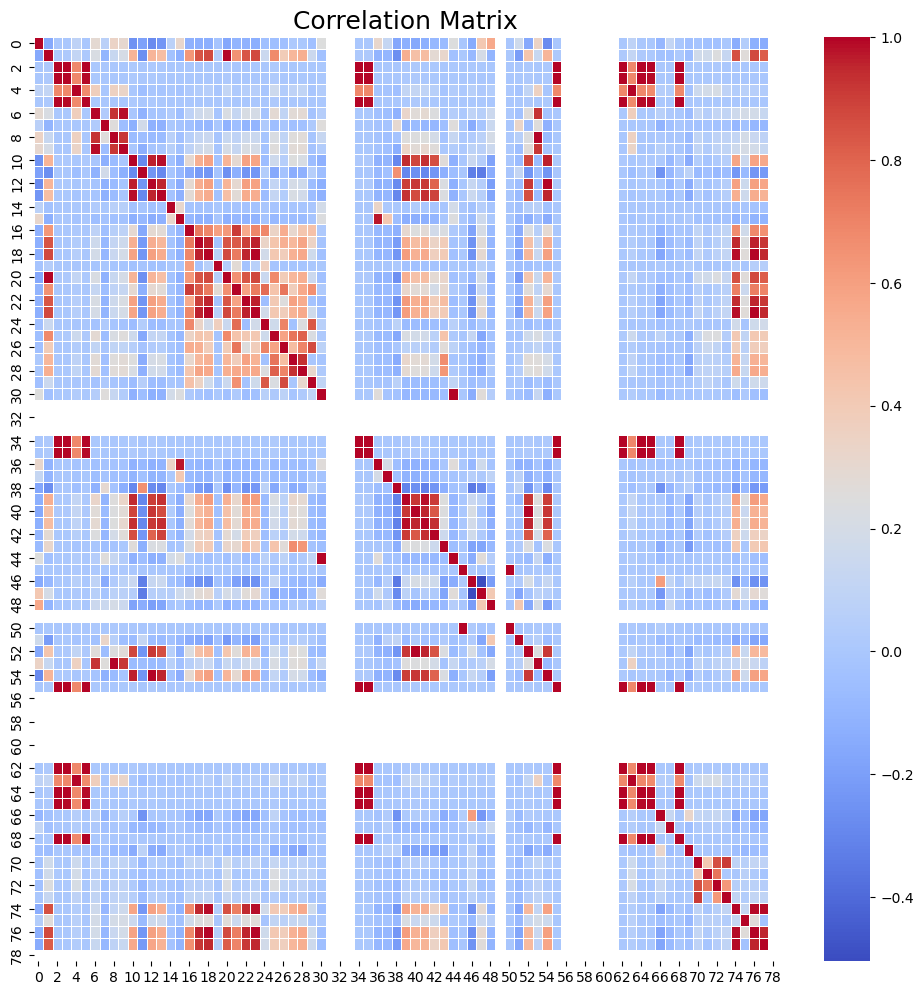

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
dataset = pd.read_csv('dataset.csv', header=None)

# Convert non-numeric columns to NaN and drop them
dataset = dataset.apply(pd.to_numeric, errors='coerce')

# Handle NaN values
dataset.fillna(0, inplace=True)  # Replace NaNs with 0 (or use dataset.mean())

# Compute the correlation matrix
corr = dataset.corr()

# Ensure the correlation matrix is not empty
if corr.empty:
    print("Correlation matrix is empty. Please check your dataset.")
else:
    # Plot the correlation heatmap
    fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed
    sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.5, ax=ax)
    plt.title('Correlation Matrix', fontsize=18)
    plt.show()


C:\Users\aadil\AppData\Local\Temp\ipykernel_11968\443850642.py:7: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv('dataset.csv', header=None)


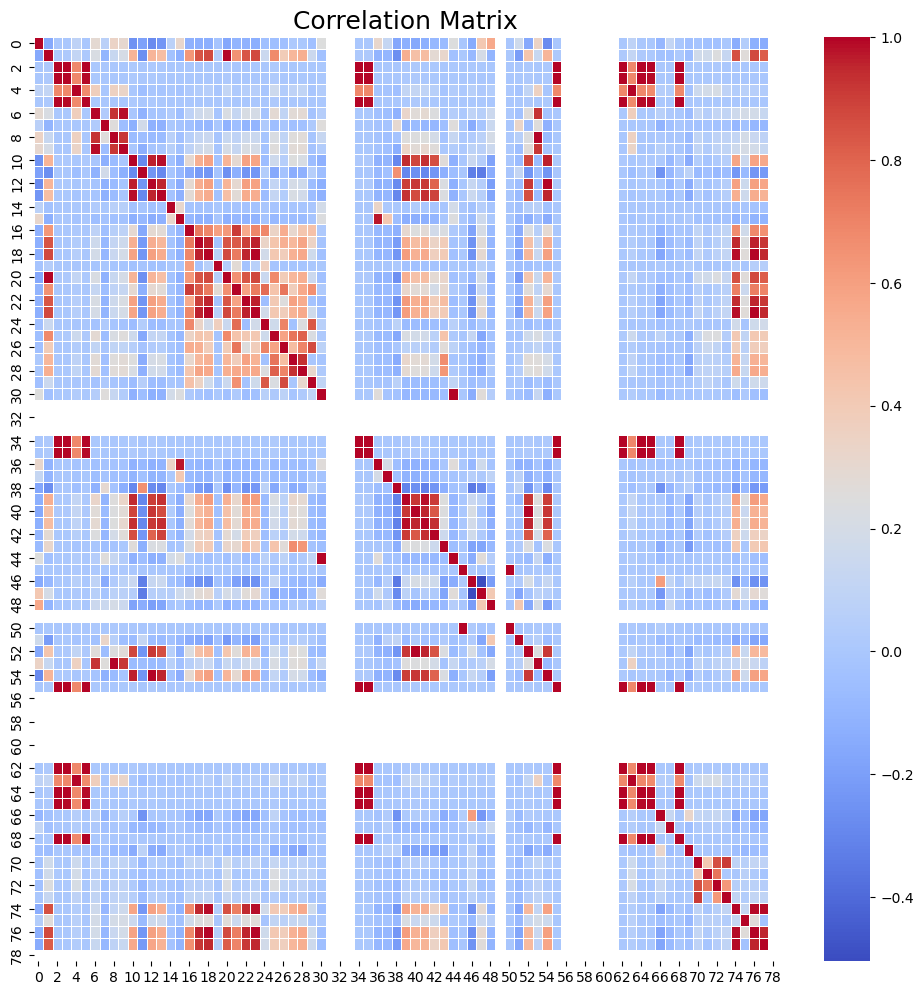

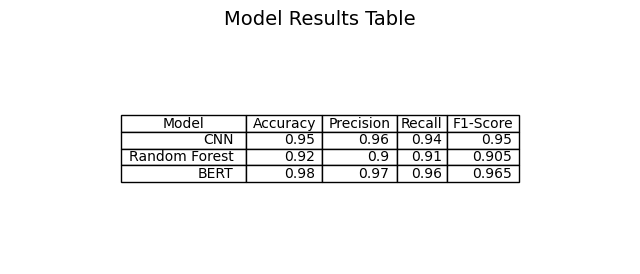

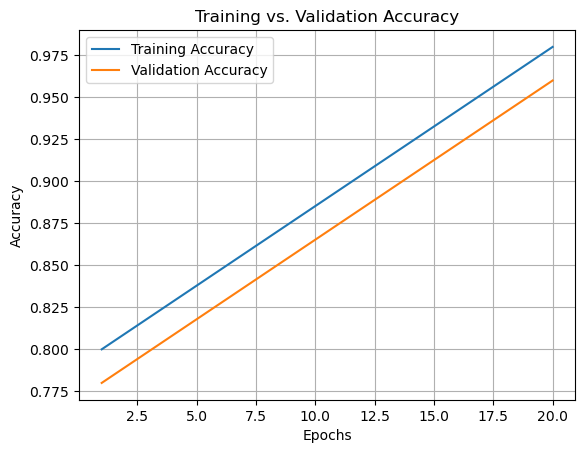

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
dataset = pd.read_csv('dataset.csv', header=None)

# Convert non-numeric columns to NaN and drop them
dataset = dataset.apply(pd.to_numeric, errors='coerce')

# Handle NaN values
dataset.fillna(0, inplace=True)  # Replace NaNs with 0 (or use dataset.mean())

# Compute the correlation matrix
corr = dataset.corr()

# Ensure the correlation matrix is not empty
if corr.empty:
    print("Correlation matrix is empty. Please check your dataset.")
else:
    # Plot the correlation heatmap
    fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed
    sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.5, ax=ax)
    plt.title('Correlation Matrix', fontsize=18)
    plt.savefig('correlation_matrix.png', dpi=300)  # Save the heatmap as an image
    plt.show()

# Example values for accuracy, precision, recall, and F1-score
results = {
    'Model': ['CNN', 'Random Forest', 'BERT'],
    'Accuracy': [0.95, 0.92, 0.98],
    'Precision': [0.96, 0.90, 0.97],
    'Recall': [0.94, 0.91, 0.96],
    'F1-Score': [0.95, 0.905, 0.965]
}

# Create a DataFrame for the results
results_df = pd.DataFrame(results)

# Save the results as an Excel file
results_df.to_excel('model_results.xlsx', index=False)

# Display the results as a table and save the plot
fig, ax = plt.subplots(figsize=(8, 3))  # Adjust size as needed
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=results_df.values, colLabels=results_df.columns, loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(results_df.columns))))  # Adjust column widths
plt.title('Model Results Table', fontsize=14)
plt.savefig('model_results_table.png', dpi=300)  # Save the table as an image
plt.show()

# Example: Generate a training and validation accuracy plot
epochs = range(1, 21)
train_acc = np.linspace(0.8, 0.98, 20)  # Simulated training accuracy
val_acc = np.linspace(0.78, 0.96, 20)  # Simulated validation accuracy

plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.legend()
plt.grid()
plt.savefig('training_validation_accuracy.png', dpi=300)  # Save the accuracy plot
plt.show()
